
# Superstore Sales & Profitability Analysis

- **Dataset:** `sample_superstore.csv`.
- **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly, SciPy


## Questions:

1. Which products generate the most profit?
2. Which region performs best?
3. Which category has high sales but low profit?




##  Import Libraries

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # --
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

#from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings("ignore")



### Load Dataset

In [218]:
raw_df = pd.read_csv("sample_superstore.csv", encoding='latin1')
raw_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88



### Dataset Overview


In [219]:

raw_df.shape


(10194, 21)

In [220]:
raw_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [221]:

raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [222]:
# Numeric summary
raw_df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,"10,194.00","10,194.00","10,194.00","10,194.00","10,194.00"
mean,"5,097.50",228.23,3.79,0.16,28.67
std,"2,942.90",619.91,2.23,0.21,232.47
min,1.00,0.44,1.00,0.00,"-6,599.98"
25%,"2,549.25",17.22,2.00,0.00,1.76
50%,"5,097.50",53.91,3.00,0.20,8.69
75%,"7,645.75",209.50,5.00,0.20,29.30
max,"10,194.00","22,638.48",14.00,0.80,"8,399.98"


In [223]:

# Categorical summary
raw_df.describe(include=["object"]).T

,count,unique,top,freq
Order ID,10194,5111,US-2026-100111,14
Order Date,10194,1242,09/05/2025,38
Ship Date,10194,1338,12/16/2024,38
Ship Mode,10194,4,Standard Class,6120
Customer ID,10194,804,WB-21850,41
Customer Name,10194,800,William Brown,41
Segment,10194,3,Consumer,5281
Country/Region,10194,2,United States,9994
City,10194,542,New York City,915
State/Province,10194,59,California,2001


In [224]:
raw_df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object


### Data Cleaning


In [225]:

df = raw_df.copy()
column_rename_map = {
    "Row ID": "row_id",
    "Order ID": "order_id",
    "Order Date": "order_date",
    "Ship Date": "ship_date",
    "Ship Mode": "ship_mode",
    "Customer ID": "customer_id",
    "Customer Name": "customer_name",
    "Segment": "segment",
    "Country/Region": "country",
    "City": "city",
    "State/Province": "state",
    "Postal Code": "postal_code",
    "Region": "region",
    "Product ID": "product_id",
    "Category": "category",
    "Sub-Category": "sub_category",
    "Product Name": "product_name",
    "Sales": "sales",
    "Quantity": "quantity",
    "Discount": "discount",
    "Profit": "profit",
}
df = df.rename(columns=column_rename_map)
df.columns


Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [226]:
df = df.drop(columns=["row_id"])
df.shape

(10194, 20)

In [227]:
df.isnull().sum()

order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

In [228]:

df.duplicated().sum()

np.int64(2)

In [229]:
# Remove duplicates
df = df.drop_duplicates()

In [230]:
# Incorrect data types & date conversion
df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y")
df["ship_date"] = pd.to_datetime(df["ship_date"], format="%m/%d/%Y")
df["quantity"] = df["quantity"].astype(int)

# sales, discount, profit are continuous monetary/ratio measures -> float
for col in ["sales", "discount", "profit"]:
    df[col] = df[col].astype(float)

df.dtypes


order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code              object
region                   object
product_id               object
category                 object
sub_category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object

In [231]:
df.head()


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.20,5.55
1,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.80,-5.49
2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.78,3,0.20,4.27
3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.20,-64.77
4,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.20,4.88



### Outlier Detection


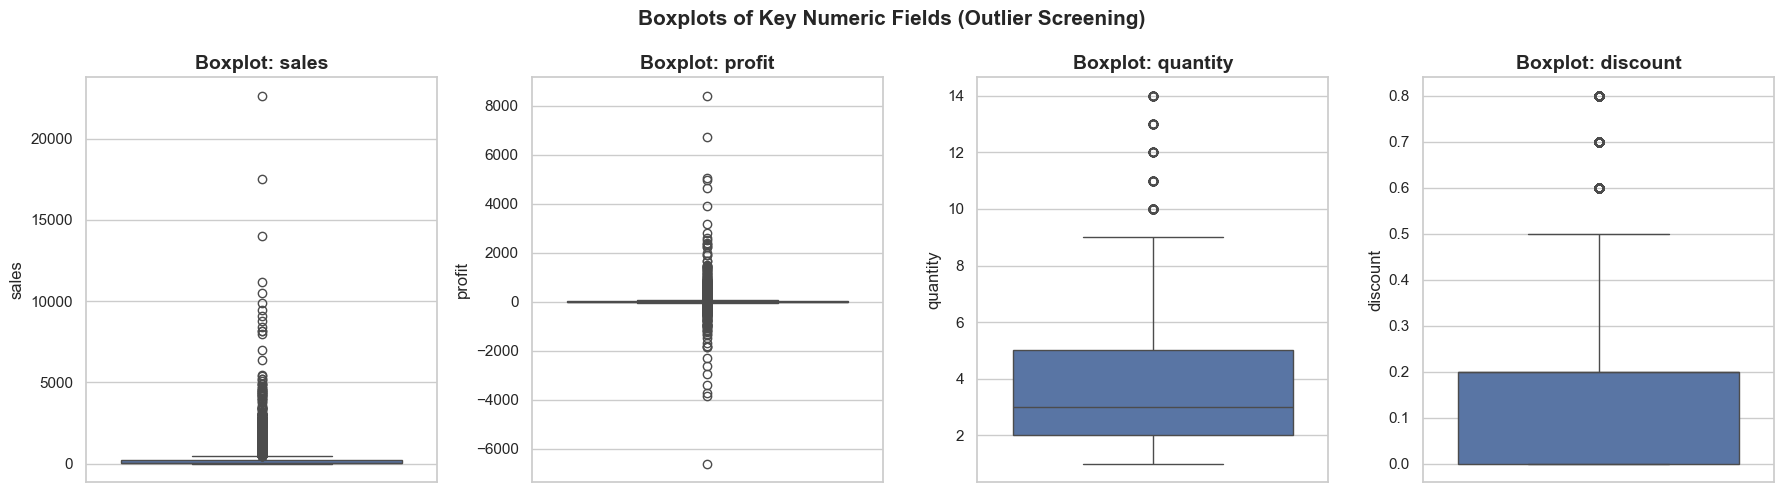

In [232]:

numeric_cols_for_outliers = ["sales", "profit", "quantity", "discount"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, numeric_cols_for_outliers):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot: {col}")
    ax.set_ylabel(col)
fig.suptitle("Boxplots of Key Numeric Fields (Outlier Screening)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [233]:

def iqr_outlier_summary(data: pd.DataFrame, column: str) -> dict:
    '''Return IQR bounds and outlier count/percentage for a numeric column.'''
    q1, q3 = data[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return {
        "column": column,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": len(outliers),
        "outlier_pct": round(len(outliers) / len(data) * 100, 2),
    }

iqr_report = pd.DataFrame([iqr_outlier_summary(df, c) for c in numeric_cols_for_outliers])
iqr_report


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,sales,17.22,209.50,192.28,-271.20,497.92,1183,11.61
1,profit,1.76,29.29,27.53,-39.53,70.58,1913,18.77
2,quantity,2.00,5.00,3.00,-2.50,9.50,175,1.72
3,discount,0.00,0.20,0.20,-0.30,0.50,874,8.58


In [234]:

# Z-score method (flags points > 3 standard deviations from the mean)
z_scores = df[numeric_cols_for_outliers].apply(stats.zscore)
z_outlier_report = pd.DataFrame({
    "column": numeric_cols_for_outliers,
    "outliers_beyond_3_sigma": (z_scores.abs() > 3).sum().values,
    "outlier_pct": ((z_scores.abs() > 3).sum().values / len(df) * 100).round(2),
})
z_outlier_report


,column,outliers_beyond_3_sigma,outlier_pct
0,sales,128,1.26
1,profit,109,1.07
2,quantity,114,1.12
3,discount,301,2.95


In [235]:

def cap_outliers_iqr(data: pd.DataFrame, column: str, factor: float = 1.5) -> pd.Series:
    '''Winsorize a column to the IQR fence, returning a capped copy (does not
    mutate the original DataFrame). Used only for modeling-ready features.'''
    q1, q3 = data[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - factor * iqr, q3 + factor * iqr
    return data[column].clip(lower=lower_bound, upper=upper_bound)

df["sales_capped"] = cap_outliers_iqr(df, "sales")
df["profit_capped"] = cap_outliers_iqr(df, "profit")

print("Original vs capped sales range:", df["sales"].max(), "->", df["sales_capped"].max())
print("Original vs capped profit range:", (df["profit"].min(), df["profit"].max()),
      "->", (df["profit_capped"].min(), df["profit_capped"].max()))


Original vs capped sales range: 22638.48 -> 497.92
Original vs capped profit range: (-6599.978, 8399.976) -> (-39.532662499999994, 70.5832375)


## Exploratory Data Analysis (EDA)

#### Univariate Analysis

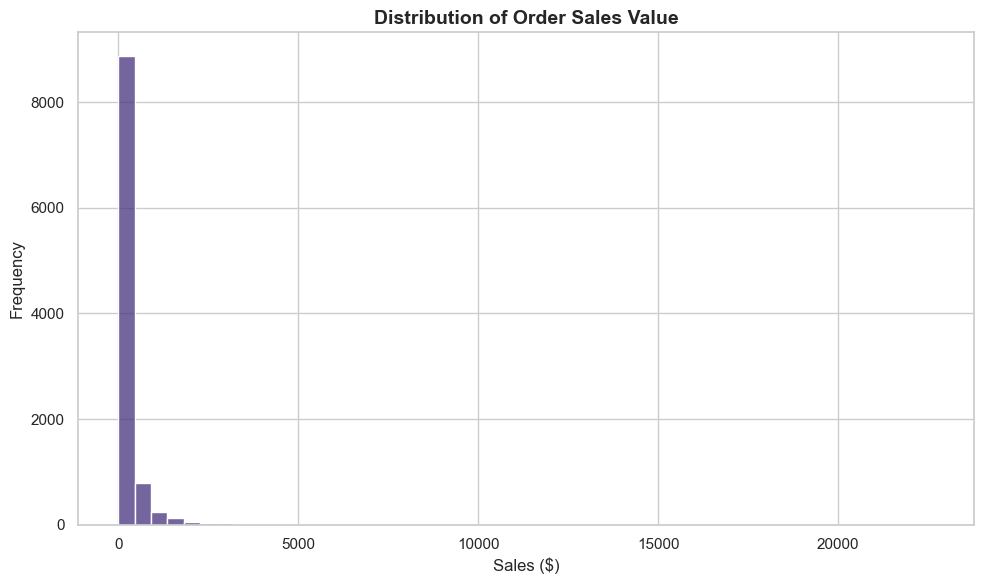

In [236]:

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df["sales"], bins=50, edgecolor="white")
plt.title("Distribution of Order Sales Value")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


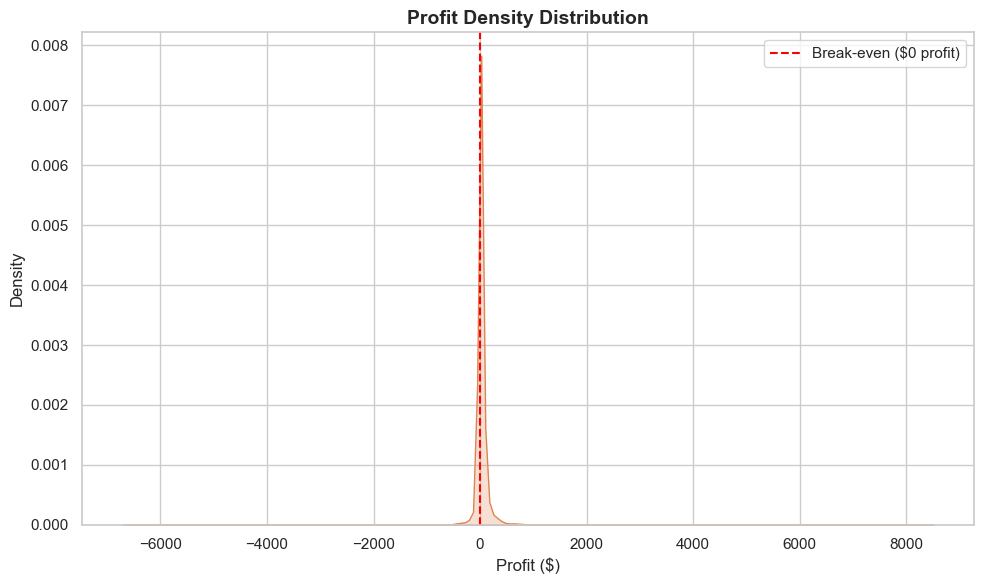

In [237]:

# KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df["profit"], fill=True, color="#DD8452")
plt.axvline(0, color="red", linestyle="--", label="Break-even ($0 profit)")
plt.title("Profit Density Distribution")
plt.xlabel("Profit ($)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


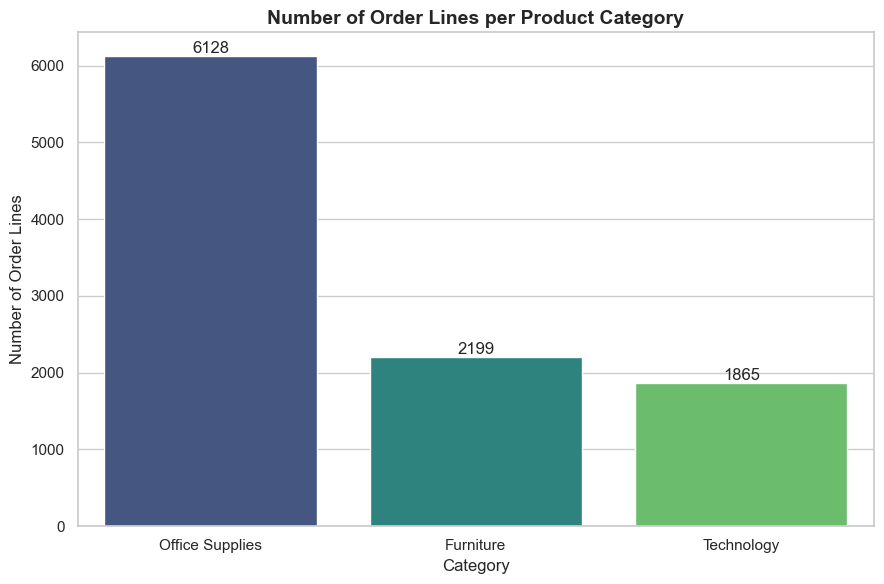

In [238]:

# Count Plot
plt.figure(figsize=(9, 6))
order_of_categories = df["category"].value_counts().index
ax = sns.countplot(data=df, x="category", order=order_of_categories, palette="viridis")
ax.set_title("Number of Order Lines per Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Order Lines")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


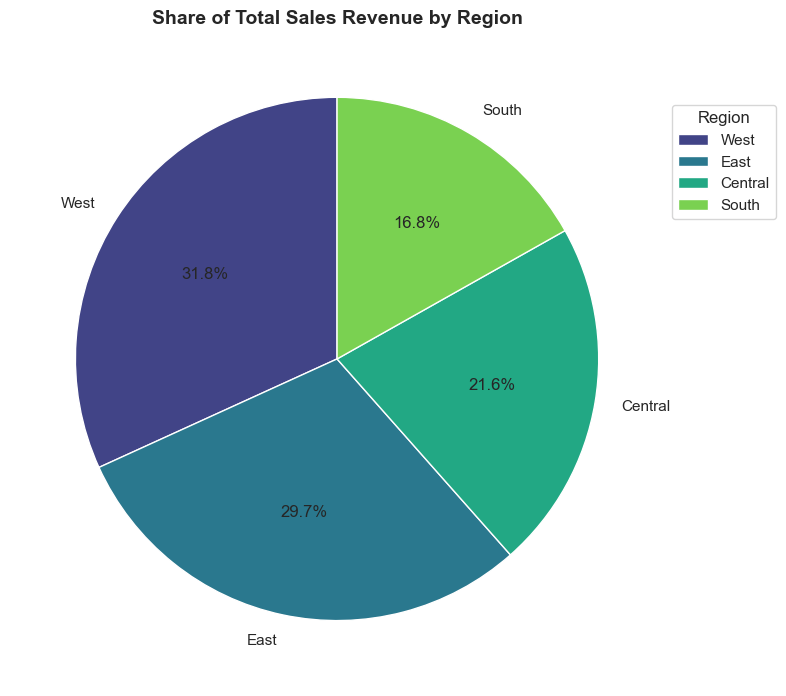

In [239]:

# Pie Chart
region_sales_share = df.groupby("region")["sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(
    region_sales_share.values,
    labels=region_sales_share.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("viridis", len(region_sales_share)),
    wedgeprops={"edgecolor": "white"},
)
plt.title("Share of Total Sales Revenue by Region")
plt.legend(region_sales_share.index, title="Region", loc="best", bbox_to_anchor=(1, 0.9))
plt.tight_layout()
plt.show()


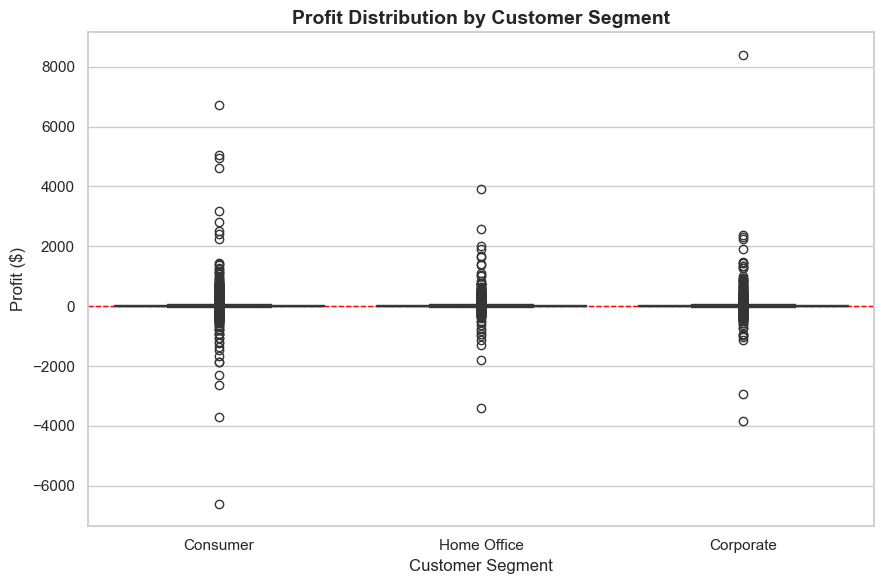

In [240]:

# Box Plot
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="segment", y="profit", palette="viridis")
plt.title("Profit Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit ($)")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()



## 7.2 Bivariate Analysis


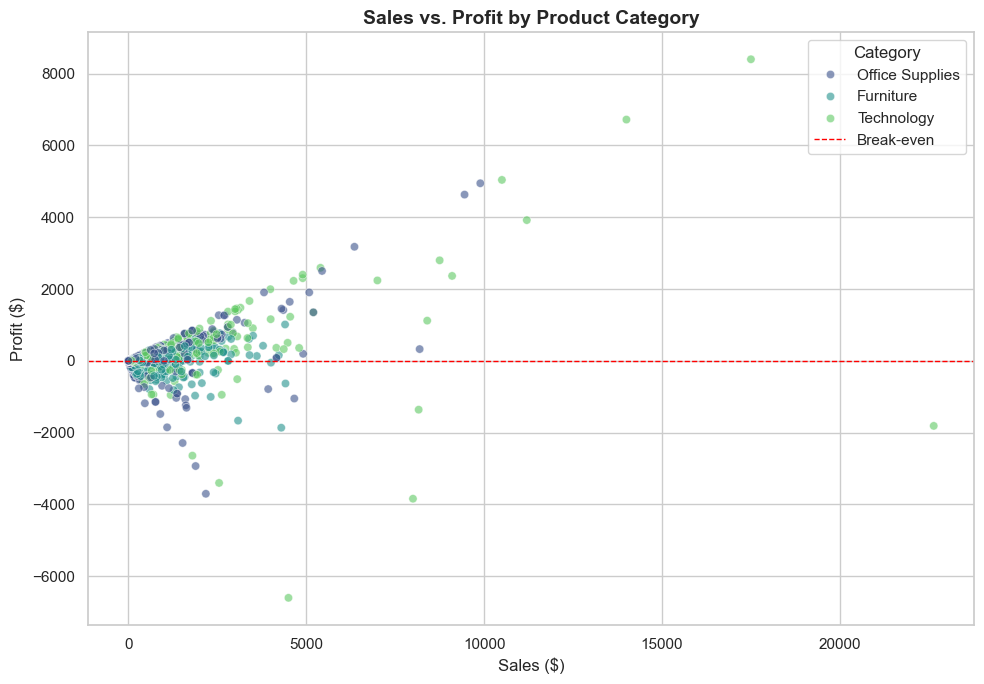

In [241]:

# Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="sales", y="profit", hue="category", alpha=0.6, palette="viridis")
plt.axhline(0, color="red", linestyle="--", linewidth=1, label="Break-even")
plt.title("Sales vs. Profit by Product Category")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


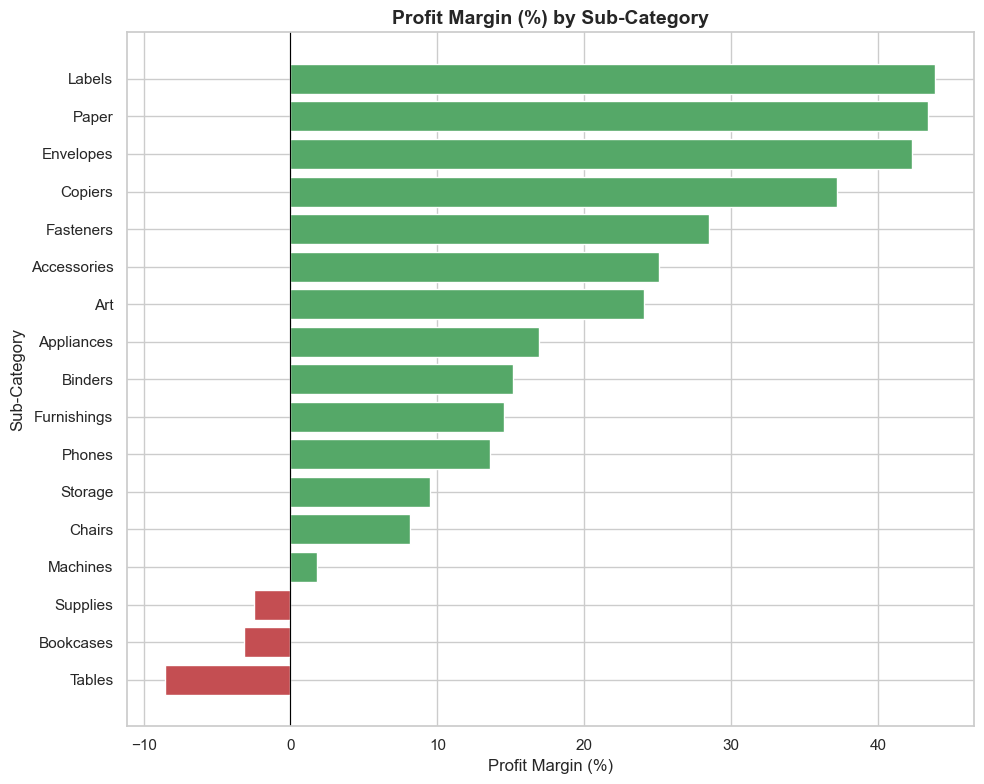

In [242]:

# Bar Plot
subcat_margin = (
    df.groupby("sub_category")
    .apply(lambda x: x["profit"].sum() / x["sales"].sum() * 100)
    .sort_values()
)

plt.figure(figsize=(10, 8))
colors = ["#C44E52" if v < 0 else "#55A868" for v in subcat_margin.values]
plt.barh(subcat_margin.index, subcat_margin.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Profit Margin (%) by Sub-Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


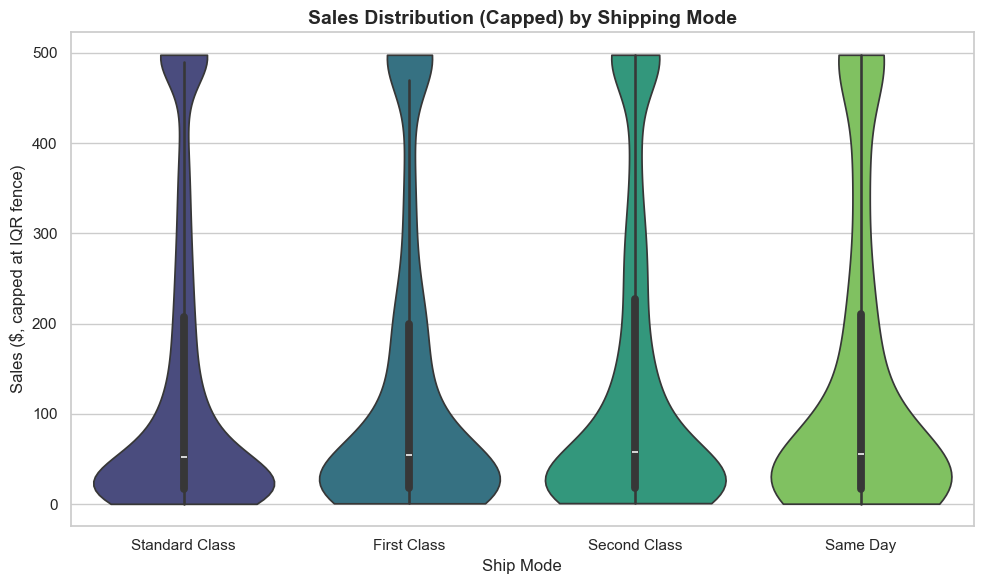

In [243]:

#Violin Plot: Sales distribution across Ship Modes ---
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="ship_mode", y="sales_capped", palette="viridis", cut=0)
plt.title("Sales Distribution (Capped) by Shipping Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales ($, capped at IQR fence)")
plt.tight_layout()
plt.show()


In [277]:
region_summary = df.groupby("region").agg(
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    orders=("order_id", "nunique"),
).assign(profit_margin_pct=lambda x: (x["total_profit"] / x["total_sales"] * 100).round(2))
region_summary.sort_values("total_sales", ascending=False)


,total_sales,total_profit,orders,profit_margin_pct
region,,,,
West,"739,813.61","110,798.82",1635,14.98
East,"691,447.68","94,859.90",1475,13.72
Central,"503,170.67","39,865.31",1179,7.92
South,"391,721.90","46,749.43",822,11.93


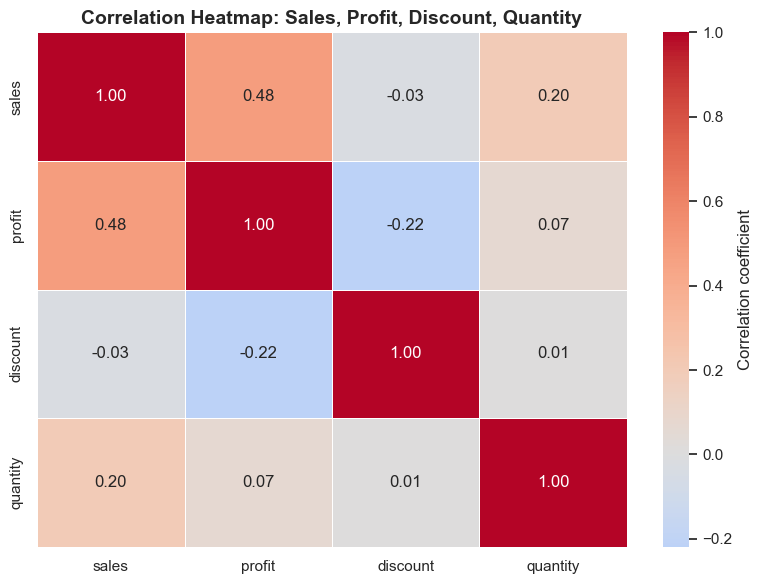

In [274]:

# Correlation Heatmap 
correlation_matrix = df[["sales", "profit", "discount", "quantity"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation coefficient"})
plt.title("Correlation Heatmap: Sales, Profit, Discount, Quantity")
plt.tight_layout()
plt.show()


In [278]:
pivot_region_category = pd.pivot_table(
    df, values="profit", index="region", columns="category", aggfunc="sum"
)
pivot_region_category


category,Furniture,Office Supplies,Technology
region,,,
Central,"-2,802.21","8,970.08","33,697.43"
East,"3,421.39","42,996.74","48,441.78"
South,"6,771.21","19,986.39","19,991.83"
West,"12,316.25","54,070.23","44,412.34"


In [283]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id',
       'customer_name', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'product_id', 'category', 'sub_category', 'product_name',
       'sales', 'quantity', 'discount', 'profit', 'sales_capped',
       'profit_capped', 'order_month', 'order_month_name', 'order_quarter',
       'order_year', 'order_weekday', 'is_weekend', 'shipping_days',
       'profit_margin_pct', 'discount_pct', 'order_total_value',
       'customer_ltv', 'customer_tenure_days', 'tenure_group',
       'spending_category', 'ship_mode_encoded', 'region_sales_rank',
       'ship_mode_code', 'order_risk_flag', 'margin_vs_category_avg'],
      dtype='object')

## Feature Engineering


In [284]:
df["profit_margin_pct"] = (df["profit"] / df["sales"] * 100).round(2)
df["discount_pct"] = (df["discount"] * 100).round(1)

order_value = df.groupby("order_id")["sales"].transform("sum")
df["order_total_value"] = order_value

customer_ltv = df.groupby("customer_id")["sales"].transform("sum")
df["customer_ltv"] = customer_ltv.round(2)

df[["order_id", "order_total_value", "customer_id", "customer_ltv",
    "profit_margin_pct", "discount_pct"]].head()


,order_id,order_total_value,customer_id,customer_ltv,profit_margin_pct,discount_pct
0,US-2023-103800,16.45,DP-13000,"1,050.64",33.75,20.00
1,US-2023-112326,288.06,PO-19195,"1,056.86",-155.00,80.00
2,US-2023-112326,288.06,PO-19195,"1,056.86",36.25,20.00
3,US-2023-112326,288.06,PO-19195,"1,056.86",-23.75,20.00
4,US-2023-141817,19.54,MB-18085,"1,428.23",25.00,20.00


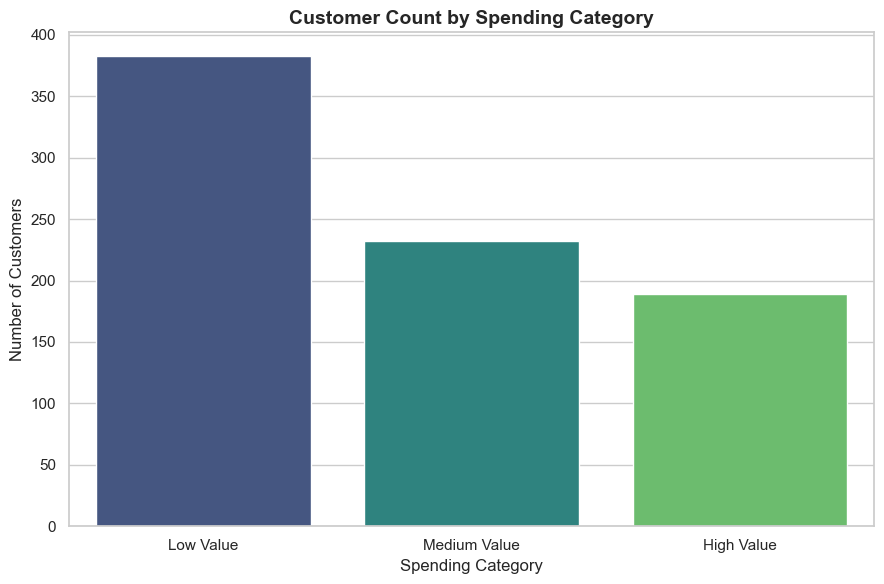

In [285]:

plt.figure(figsize=(9, 6))
sns.countplot(data=df.drop_duplicates("customer_id"), x="spending_category",
              order=["Low Value", "Medium Value", "High Value"], palette="viridis")
plt.title("Customer Count by Spending Category")
plt.xlabel("Spending Category")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## Statistical Analysis

Correlation

In [287]:

correlation_matrix = df[["sales", "profit", "discount", "quantity"]].corr()
correlation_matrix.round(3)

,sales,profit,discount,quantity
sales,1.00,0.48,-0.03,0.20
profit,0.48,1.00,-0.22,0.07
discount,-0.03,-0.22,1.00,0.01
quantity,0.20,0.07,0.01,1.00


Skewness & Distribution Shape

In [270]:

skewness_report = df[["sales", "profit", "quantity", "discount"]].skew().round(2).to_frame("skewness")
skewness_report["interpretation"] = skewness_report["skewness"].apply(
    lambda s: "Highly right-skewed" if s > 1 else
              "Moderately right-skewed" if s > 0.5 else
              "Approximately symmetric" if abs(s) <= 0.5 else
              "Left-skewed"
)
skewness_report


,skewness,interpretation
sales,12.98,Highly right-skewed
profit,7.60,Highly right-skewed
quantity,1.27,Highly right-skewed
discount,1.69,Highly right-skewed


Normality Testing

In [289]:
statistic, p_value = stats.normaltest(df["profit"])
alpha = 0.05
if p_value < alpha:
    print("Result: Profit is NOT normally distributed.")
else:
    print("Result: Profit looks normally distributed.")


Result: Profit is NOT normally distributed.


Hypothesis Test — Does Discount Level Significantly Affect Profit?

In [290]:
low_discount_profit = df.loc[df["discount"] < 0.2, "profit_margin_pct"]
high_discount_profit = df.loc[df["discount"] >= 0.2, "profit_margin_pct"]

t_stat, p_val = stats.ttest_ind(low_discount_profit, high_discount_profit, equal_var=False)
if p_val < 0.05:
    print("Result: statistically significant difference in profit margin between "
          "low- and high-discount orders (p < 0.05).")
else:
    print("Result: no statistically significant difference detected (p >= 0.05).")


Result: statistically significant difference in profit margin between low- and high-discount orders (p < 0.05).


ANOVA — Does Average Profit Margin Differ Across Regions?

In [ ]:

region_groups = [group["profit_margin_pct"].values for _, group in df.groupby("region")]
f_stat, p_val_anova = stats.f_oneway(*region_groups)

if p_val_anova < 0.05:
    print("Result: at least one region's average profit margin differs "
          "significantly from the others (p < 0.05).")
else:
    print("Result: no statistically significant difference across regions (p >= 0.05).")


One-way ANOVA across regions: F-statistic=268.23, p-value=1.455e-167
Result: at least one region's average profit margin differs significantly from the others (p < 0.05).
